In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# VCM CH4 FaIR analysis

This analysis uses `retired-ch4-only` credits by vintage from `vcm_vintage_timeseries.csv`.

The VCM export identifies the vintage of credits that were eventually retired, but not the calendar year in which each credit was retired. For this analysis, both the CH4 project reduction and the associated justified CO2 emission are assigned to the credit vintage year.

The main accounting case uses IPCC AR6 non-fossil CH4 GWP100 = 27.0. GWP and GTP alternatives are treated as sensitivity tests.

The climate analysis is aligned with the updated California offset analysis and Hughes et al. (2026): the full 841-member calibrated and constrained FaIR ensemble from calibration v1.4.1, SSP1-2.6 as the common baseline, and v.1.4.0 parameters for CH4 lifetime. The reported central trajectory is the median across the 841 paired ensemble responses.

In [7]:
# ----------------------------
# inputs
# ----------------------------

VCM_FILE = "../timeseries-data/output-data/vcm_vintage_timeseries.csv"

# calibration v1.4.1 provides the constrained 841-member climate/carbon-cycle ensemble
FAIR_PARAMS_FILE = "../timeseries-data/input-data/fair/calibrated_constrained_parameters_calibration1.4.1.csv"

# full species parameters corresponding to calibration v1.4.1
FAIR_SPECIES_CONFIG_FILE = "../timeseries-data/input-data/fair/species_configs_properties_calibration1.4.1.csv"

# Hughes et al. (2026) baseline
BASELINE_SCENARIO = "ssp126"
START_YEAR = 1750
END_YEAR = 2200
ANALYSIS_START = 1996

# IPCC AR6 non-fossil CH4 GWP100 and sensitivity values
EQUIV_METRICS = {"GWP100": 27.0, "GWP20": 84, "GWP500": 8, "GTP20": 67, "GTP50": 14, "GTP100": 4,}

## 01 - Load retired CH4-only credits by vintage

In [8]:
# ----------------------------
# load VCM data
# ----------------------------

df = pd.read_csv(VCM_FILE).sort_values("vintage_year").fillna(0)

required = ["vintage_year", "issued-ch4-only", "retired-ch4-only", "remaining-ch4-only"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

assert np.allclose(df["issued-ch4-only"], df["retired-ch4-only"] + df["remaining-ch4-only"])

vcm = df.set_index("vintage_year")
retired = vcm["retired-ch4-only"].astype(float)

print(f"Retired CH4-only credits: {retired.sum()/1e6:,.2f} MtCO2e")
print(f"Vintage range: {int(vcm.index.min())}-{int(vcm.index.max())}")

Retired CH4-only credits: 139.72 MtCO2e
Vintage range: 1996-2026


## 02 - Convert credits to physical project and justified-emissions fluxes

For each equivalency metric:
- CH4 project reduction = `retired credits / metric value`
- justified CO2 emission = `retired credits`

Both fluxes are assigned to the vintage year because retirement-year information is not available in this dataset.

In [18]:
# ----------------------------
# build annual perturbation fluxes
# ----------------------------

def make_fluxes(metric_value):
    return pd.DataFrame(index=vcm.index, data={
        "ch4_flux": -retired / metric_value,  # tonnes CH4
        "co2_flux": retired,                  # tonnes CO2
    })

fluxes = {metric: make_fluxes(value) for metric, value in EQUIV_METRICS.items()}
fluxes["GWP100"].head()

,ch4_flux,co2_flux
vintage_year,,
1996,-0.000000,0.0
1997,-0.000000,0.0
1998,-12.222222,330.0
1999,-242.481481,6547.0
2000,-489.148148,13207.0


## 03 - Hughes-matched FaIR configuration

The primary analysis uses the 841-member calibrated and constrained FaIR ensemble from calibration v1.4.1. We use the full FaIR species configuration and SSP1-2.6 as the common background scenario to match Hughes et al. (2026) and the updated California offset analysis.

Methane lifetime treatment: calibration v1.4.1 produces an unrealistically long methane lifetime because it's calibrated to an updated historical methane emissions inventory. Following Hughes et al. (2026), we use the v1.4.1 constrained ensemble and `ch4_method="Thornhill2021"` for the climate and carbon-cycle parameters but replace the methane lifetime parameters with those from calibration v1.4.0. 

In [10]:
# ----------------------------
# configure calibrated/constrained ensemble and SSP1-2.6 baseline
# ----------------------------

df_configs = pd.read_csv(FAIR_PARAMS_FILE, index_col=0)
ensemble_configs = df_configs.index

# use the full v1.4.1 species configuration
species_ens, properties_ens = read_properties(filename=FAIR_SPECIES_CONFIG_FILE)

# load SSP1-2.6 once, before expanding to all ensemble members
f_base = FAIR(ch4_method="Thornhill2021")
f_base.define_time(START_YEAR, END_YEAR, 1)
f_base.define_scenarios([BASELINE_SCENARIO])
f_base.define_configs(["central"])
f_base.define_species(species_ens, properties_ens)
f_base.allocate()
f_base.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
f_base.fill_from_rcmip()

# v1.4.0 methane lifetime parameters, following Hughes et al. (2026)
ch4_v140 = pd.read_csv("https://zenodo.org/records/10566646/files/CH4_lifetime.csv?download=1").iloc[0]

print(f"Configured {len(ensemble_configs)} ensemble members.")

Configured 841 ensemble members.


In [11]:
# ----------------------------
# helper: create and run paired FaIR scenarios
# ----------------------------

def run_program_fair(flux, scenarios=("projects_only", "emissions_only", "net_program"), progress=False):
    run_scenarios = [BASELINE_SCENARIO, *scenarios]

    f_run = FAIR(ch4_method="Thornhill2021")
    f_run.define_time(START_YEAR, END_YEAR, 1)
    f_run.define_scenarios(run_scenarios)
    f_run.define_configs(ensemble_configs)
    f_run.define_species(species_ens, properties_ens)
    f_run.allocate()

    # v1.4.1 constrained ensemble
    f_run.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
    f_run.override_defaults(FAIR_PARAMS_FILE)

    # replace v1.4.1 methane lifetime parameters with v1.4.0 values
    fill(f_run.species_configs["unperturbed_lifetime"], ch4_v140["base"], specie="CH4")
    fill(f_run.species_configs["lifetime_temperature_sensitivity"], ch4_v140["temp"])
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["CH4"], specie="CH4")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["N2O"], specie="N2O")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["HC"], specie="Equivalent effective stratospheric chlorine")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["NOx"], specie="NOx")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["VOC"], specie="VOC")

    # isolate parametric ensemble uncertainty
    fill(f_run.climate_configs["stochastic_run"], False)
    fill(f_run.climate_configs["use_seed"], False)

    # copy the same SSP1-2.6 background into every scenario and ensemble member
    base_emissions = f_base.emissions.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_concentration = f_base.concentration.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_forcing = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central").values

    for scen in run_scenarios:
        f_run.emissions.loc[dict(scenario=scen)].values[:] = base_emissions[:, None, :]
        f_run.concentration.loc[dict(scenario=scen)].values[:] = base_concentration[:, None, :]
        f_run.forcing.loc[dict(scenario=scen)].values[:] = base_forcing[:, None, :]

    timepoints = np.asarray(f_run.timepoints, dtype=float)

    # add physical CH4 project reductions and credit-justified CO2 emissions
    for year, row in flux.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(year)))]
        ch4 = row["ch4_flux"] / 1e6
        co2 = row["co2_flux"] / 1e9

        for scen in ["projects_only", "net_program"]:
            if scen in scenarios:
                f_run.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CH4")].values += ch4

        for scen in ["emissions_only", "net_program"]:
            if scen in scenarios:
                f_run.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CO2 FFI")].values += co2

    # initialize from calibrated baseline concentrations
    initialise(f_run.concentration, f_run.species_configs["baseline_concentration"])
    initialise(f_run.forcing, 0.0)
    initialise(f_run.temperature, 0.0)
    initialise(f_run.cumulative_emissions, 0.0)
    initialise(f_run.airborne_emissions, 0.0)
    initialise(f_run.ocean_heat_content_change, 0.0)

    # restore SSP1-2.6 solar and volcanic forcing after initialization,
    # including member-specific calibrated forcing scales
    for scen in run_scenarios:
        for sp in ["Solar", "Volcanic"]:
            if sp in species_ens:
                base = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values[:, None]
                scale_col = f"forcing_scale[{sp}]"
                scales = (df_configs[scale_col].values
                    if scale_col in df_configs.columns
                    else np.ones(len(ensemble_configs)))
                f_run.forcing.loc[dict(scenario=scen, specie=sp)].values[:] = base * scales[None, :]

    f_run.run(progress=progress)
    return f_run

## 04 - Main GWP100 ensemble run

The GWP100 case is the primary analysis. Every perturbation scenario is paired with the same SSP1-2.6 baseline within each of the 841 calibrated ensemble members. Component and net temperature responses below are medians of those paired differences.

In [12]:
# ----------------------------
# run main GWP100 ensemble
# ----------------------------

print("Running GWP100 baseline + component scenarios...")
start = time.time()
f = run_program_fair(fluxes["GWP100"], progress=True)
print(f"Ensemble complete in {time.time() - start:.1f} seconds.")

years = np.asarray(f.timebounds, dtype=float)
baseline_ensemble = f.temperature.sel(scenario=BASELINE_SCENARIO, layer=0)

temperature_ensemble = {scen: f.temperature.sel(scenario=scen, layer=0) - baseline_ensemble
    for scen in ["projects_only", "emissions_only", "net_program"]}

temperature = {scen: response.median("config").values
    for scen, response in temperature_ensemble.items()}

net_lower = temperature_ensemble["net_program"].quantile(0.05, dim="config").values
net_upper = temperature_ensemble["net_program"].quantile(0.95, dim="config").values

Running GWP100 baseline + component scenarios...


Running 3364 projections in parallel: 100%|█| 450/450 [00:13<00:00, 33.41timeste


Ensemble complete in 22.8 seconds.


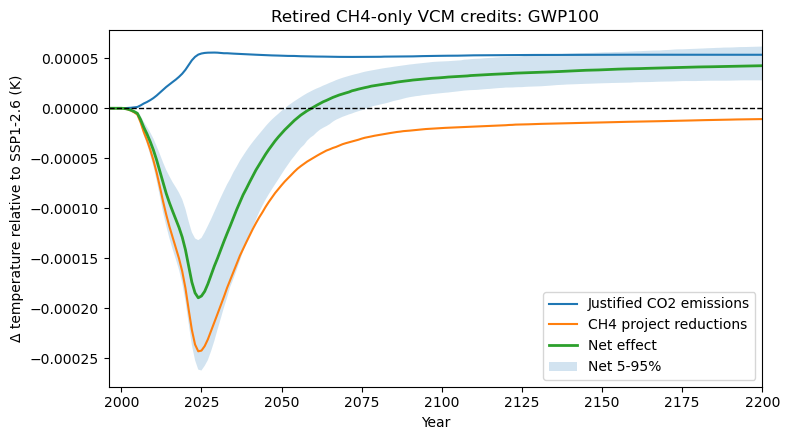

In [13]:
# ----------------------------
# plot main temperature components
# ----------------------------

plt.figure(figsize=(8, 4.5))
plt.plot(years, temperature["emissions_only"], label="Justified CO2 emissions")
plt.plot(years, temperature["projects_only"], label="CH4 project reductions")
plt.plot(years, temperature["net_program"], linewidth=2, label="Net effect")
plt.fill_between(years, net_lower, net_upper, alpha=0.2, label="Net 5-95%")
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlim(ANALYSIS_START, END_YEAR)
plt.xlabel("Year")
plt.ylabel("Δ temperature relative to SSP1-2.6 (K)")
plt.title("Retired CH4-only VCM credits: GWP100")
plt.legend()
plt.tight_layout()
plt.show()

## 05 - Temperature metrics and crossover uncertainty

The crossover is the first transition from a net cooling effect to a net warming effect after the start of the VCM analysis period, with linear interpolation between annual time steps.

The central values below are calculated from the **median paired ensemble trajectory**. We also calculate each metric independently for all 841 ensemble members to characterize parametric uncertainty.

In [14]:
# ----------------------------
# temperature metrics
# ----------------------------

def crossover_year(years, temp, start=ANALYSIS_START):
    years = np.asarray(years)
    temp = np.asarray(temp)
    mask = years >= start
    y, t = years[mask], temp[mask]
    idx = np.where((t[:-1] < 0) & (t[1:] >= 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    return y[i] - t[i] * (y[i + 1] - y[i]) / (t[i + 1] - t[i])

def temp_metrics(years, temp):
    mask = np.asarray(years) >= ANALYSIS_START
    y, t = np.asarray(years)[mask], np.asarray(temp)[mask]
    return {
        "crossover_year": crossover_year(y, t),
        "peak_cooling_k": t.min(),
        "peak_cooling_year": y[np.argmin(t)],
        "peak_warming_k": t.max(),
        "peak_warming_year": y[np.argmax(t)],
        "integrated_k_year": np.trapz(t, y),
        "temp_2050_k": np.interp(2050, y, t),
        "temp_2100_k": np.interp(2100, y, t),
        "temp_2200_k": np.interp(2200, y, t),
    }

central_metrics = pd.DataFrame([temp_metrics(years, temperature["net_program"])], index=["GWP100 ensemble median"])
display(central_metrics.round(8))

,crossover_year,peak_cooling_k,peak_cooling_year,peak_warming_k,peak_warming_year,integrated_k_year,temp_2050_k,temp_2100_k,temp_2200_k
GWP100 ensemble median,2059.373706,-0.00019,2024.0,0.000043,2200.0,0.000176,-0.000025,0.000031,0.000043


In [15]:
# ----------------------------
# ensemble uncertainty in summary metrics
# ----------------------------

net_program_ensemble = temperature_ensemble["net_program"]

ensemble_metrics = pd.DataFrame([temp_metrics(years, net_program_ensemble.sel(config=config).values)
    for config in net_program_ensemble.config.values])

ensemble_summary = pd.DataFrame({
    "median": ensemble_metrics.median(),
    "p05": ensemble_metrics.quantile(0.05),
    "p95": ensemble_metrics.quantile(0.95),})

crossovers = ensemble_metrics["crossover_year"].dropna().values
print(f"Median-trajectory crossover: {crossover_year(years, temperature['net_program']):.1f}")
print(f"Ensemble crossover distribution: {np.median(crossovers):.1f} ± {np.std(crossovers, ddof=1):.1f} years (median ± SD)")
display(ensemble_summary.round(8))

Median-trajectory crossover: 2059.4
Ensemble crossover distribution: 2059.4 ± 8.0 years (median ± SD)


,median,p05,p95
crossover_year,2059.408068,2051.030141,2076.711009
peak_cooling_k,-0.000190,-0.000264,-0.000132
peak_cooling_year,2024.000000,2024.000000,2025.000000
peak_warming_k,0.000043,0.000028,0.000062
peak_warming_year,2200.000000,2131.000000,2200.000000
integrated_k_year,0.000179,-0.002477,0.002304
temp_2050_k,-0.000025,-0.000066,-0.000003
temp_2100_k,0.000031,0.000015,0.000047
temp_2200_k,0.000043,0.000028,0.000062


## 06 - GWP and GTP sensitivity tests

These sensitivity tests use the **same Hughes-matched 841-member FaIR configuration** as the primary analysis. Only the conversion from retired tCO2e credits to physical CH4 project reductions changes. The number of retired credits, and therefore the associated justified CO2 emissions, remains unchanged.

Each sensitivity result is reported as the median of the 841 paired `net_program - SSP1-2.6` temperature responses.

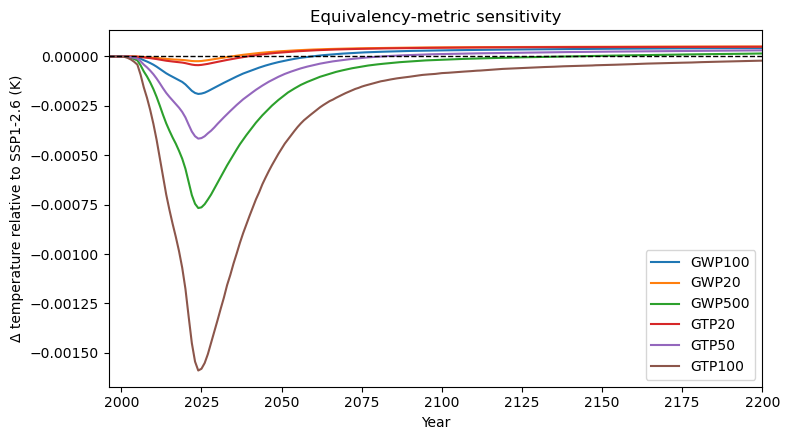

In [17]:
# ----------------------------
# plot metric sensitivity
# ----------------------------

plt.figure(figsize=(8, 4.5))

for metric, result in sensitivity.items():
    plt.plot(years, result["temperature"], label=metric)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlim(ANALYSIS_START, END_YEAR)
plt.xlabel("Year")
plt.ylabel("Δ temperature relative to SSP1-2.6 (K)")
plt.title("Equivalency-metric sensitivity")
plt.legend()
plt.tight_layout()
plt.show()